In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set style for better looking graphs
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")

In [2]:
# Load the cleaned data from Notebook 1
df = pd.read_csv('../data/processed/cleaned_customers.csv')

print(f"Data loaded: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"Columns: {df.columns.tolist()}")

Data loaded: 2058 rows, 33 columns
Columns: ['Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome', 'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Response', 'Age', 'Customer_Year', 'Customer_Month', 'Customer_Day', 'Days_As_Customer', 'Marital_Status_Clean', 'Education_Level']


# 1. Feature Engineering

### 1.1 Spending Features

In [3]:
# Total spending across all products
spending_cols = ['MntWines', 'MntFruits', 'MntMeatProducts', 
                 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
df['Total_Spending'] = df[spending_cols].sum(axis=1)

# Average spending per product category
df['Avg_Spending_Per_Category'] = df['Total_Spending'] / 6

# Spending per person (accounting for family size)
df['Spending_Per_Capita'] = df['Total_Spending'] / (df['Kidhome'] + df['Teenhome'] + 1)

print("Spending features created:")
print(f"   - Total_Spending range: ${df['Total_Spending'].min():,.0f} to ${df['Total_Spending'].max():,.0f}")
print(f"   - Spending_Per_Capita range: ${df['Spending_Per_Capita'].min():,.0f} to ${df['Spending_Per_Capita'].max():,.0f}")

Spending features created:
   - Total_Spending range: $5 to $2,525
   - Spending_Per_Capita range: $2 to $2,525


### 1.2 Purchase Behavior Features

In [4]:
# Total number of purchases across all channels
purchase_cols = ['NumDealsPurchases', 'NumWebPurchases', 
                 'NumCatalogPurchases', 'NumStorePurchases']
df['Total_Purchases'] = df[purchase_cols].sum(axis=1)

# Online purchase ratio (how much they buy online vs offline)
df['Online_Purchase_Ratio'] = df['NumWebPurchases'] / (df['Total_Purchases'] + 1)

# Deal purchase ratio (how much they buy using deals/discounts)
df['Deal_Purchase_Ratio'] = df['NumDealsPurchases'] / (df['Total_Purchases'] + 1)

# Average spending per purchase
df['Spending_Per_Purchase'] = df['Total_Spending'] / (df['Total_Purchases'] + 1)

print("Purchase behavior features created:")
print(f"   - Total_Purchases range: {df['Total_Purchases'].min()} to {df['Total_Purchases'].max()}")
print(f"   - Online_Purchase_Ratio range: {df['Online_Purchase_Ratio'].min():.2f} to {df['Online_Purchase_Ratio'].max():.2f}")

Purchase behavior features created:
   - Total_Purchases range: 0 to 44
   - Online_Purchase_Ratio range: 0.00 to 0.96


### 1.3 Campaign Engagement Features

In [5]:
# Total campaigns accepted in the past
campaign_cols = ['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5']
df['Total_Campaigns_Accepted'] = df[campaign_cols].sum(axis=1)

# Campaign success rate
df['Campaign_Success_Rate'] = df['Total_Campaigns_Accepted'] / 5

# Whether customer has accepted any past campaign
df['Has_Accepted_Any_Campaign'] = (df['Total_Campaigns_Accepted'] > 0).astype(int)

# Whether customer is a loyal responder (accepted 2+ campaigns)
df['Is_Loyal_Responder'] = (df['Total_Campaigns_Accepted'] >= 2).astype(int)

print("Campaign engagement features created:")
print(f"   - Total_Campaigns_Accepted: {df['Total_Campaigns_Accepted'].value_counts().sort_index().to_dict()}")
print(f"   - Has_Accepted_Any_Campaign: {df['Has_Accepted_Any_Campaign'].value_counts().to_dict()}")

Campaign engagement features created:
   - Total_Campaigns_Accepted: {0: 1627, 1: 304, 2: 77, 3: 40, 4: 10}
   - Has_Accepted_Any_Campaign: {0: 1627, 1: 431}


### 1.4 Customer Value Features

In [6]:
# Customer Lifetime Value proxy (spending * purchases / age)
df['CLV_Score'] = (df['Total_Spending'] * df['Total_Purchases']) / (df['Age'] + 1)

# Income per family member
df['Income_Per_Capita'] = df['Income'] / (df['Kidhome'] + df['Teenhome'] + 1)

# Spending as percentage of income (how much they spend vs earn)
df['Spending_to_Income_Ratio'] = (df['Total_Spending'] / (df['Income'] + 1)) * 100

# Engagement score (combination of web visits and purchases)
df['Engagement_Score'] = (df['NumWebVisitsMonth'] * df['Total_Purchases']) / (df['Recency'] + 1)

print("Customer value features created:")
print(f"   - CLV_Score range: {df['CLV_Score'].min():.0f} to {df['CLV_Score'].max():.0f}")
print(f"   - Spending_to_Income_Ratio range: {df['Spending_to_Income_Ratio'].min():.1f}% to {df['Spending_to_Income_Ratio'].max():.1f}%")

Customer value features created:
   - CLV_Score range: 0 to 1877
   - Spending_to_Income_Ratio range: 0.0% to 70.7%


### View All New Features

In [7]:
new_features = ['Total_Spending', 'Avg_Spending_Per_Category', 'Spending_Per_Capita',
                'Total_Purchases', 'Online_Purchase_Ratio', 'Deal_Purchase_Ratio', 'Spending_Per_Purchase',
                'Total_Campaigns_Accepted', 'Campaign_Success_Rate', 'Has_Accepted_Any_Campaign', 'Is_Loyal_Responder',
                'CLV_Score', 'Income_Per_Capita', 'Spending_to_Income_Ratio', 'Engagement_Score']

print("="*60)
print("NEW FEATURES CREATED")
print("="*60)
for feature in new_features:
    if feature in df.columns:
        print(f"{feature}")
    else:
        print(f"{feature} (not found)")

print(f"\nTotal columns now: {len(df.columns)}")

NEW FEATURES CREATED
Total_Spending
Avg_Spending_Per_Category
Spending_Per_Capita
Total_Purchases
Online_Purchase_Ratio
Deal_Purchase_Ratio
Spending_Per_Purchase
Total_Campaigns_Accepted
Campaign_Success_Rate
Has_Accepted_Any_Campaign
Is_Loyal_Responder
CLV_Score
Income_Per_Capita
Spending_to_Income_Ratio
Engagement_Score

Total columns now: 48


# 2. Customer Segmentation (Clustering)

## 2.1 Feature Selection for Customer Segmentation

### Experiment with Different Combinations of columns

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

# Define 4 different feature combinations to test
feature_sets = {
    "Combination 1 (Economic Focus)": [
        'Income', 'Total_Spending', 'Spending_Per_Capita'
    ],
    "Combination 2 (Behavior Focus)": [
        'Online_Purchase_Ratio', 'Total_Purchases', 'Campaign_Success_Rate', 'Recency'
    ],
    "Combination 3 (Demographic Focus)": [
        'Age', 'Income', 'Education_Level', 'Has_Children'
    ],
    "Combination 4 (Full - My Choice)": [
        'Income', 'Total_Spending', 'Total_Purchases', 'Age',
        'Online_Purchase_Ratio', 'Spending_Per_Capita', 'Campaign_Success_Rate'
    ]
}

# Store results
experiment_results = []

print("="*70)
print("EXPERIMENT: Testing Different Feature Combinations for Clustering")
print("="*70)

for name, features in feature_sets.items():
    # Check which features exist
    available = [f for f in features if f in df.columns]
    
    if len(available) < 2:
        print(f"\n {name}: Not enough features available (need at least 2)")
        continue
    
    # Prepare data
    Z = df[available].copy()
    
    # Scale features
    scaler = StandardScaler()
    Z_scaled = scaler.fit_transform(Z)
    
    # Apply K-Means with k=4
    kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
    clusters = kmeans.fit_predict(Z_scaled)
    
    # Calculate silhouette score (higher = better separation)
    sil_score = silhouette_score(Z_scaled, clusters)
    
    # Store results
    experiment_results.append({
        'Combination': name,
        'Features_Used': len(available),
        'Features_List': ', '.join(available[:5]) + ('...' if len(available) > 5 else ''),
        'Silhouette_Score': sil_score
    })
    
    print(f"\n{name}")
    print(f"   Features: {len(available)} features")
    print(f"   Silhouette Score: {sil_score:.4f}")

# Display comparison
print("\n" + "="*70)
print("COMPARISON RESULTS (Higher Silhouette = Better Separation)")
print("="*70)

results_df = pd.DataFrame(experiment_results)
results_df = results_df.sort_values('Silhouette_Score', ascending=False)
print(results_df.to_string(index=False))

# Find best combination
best = results_df.iloc[0]
print(f"\nBEST COMBINATION: {best['Combination']}")
print(f"   Silhouette Score: {best['Silhouette_Score']:.4f}")

EXPERIMENT: Testing Different Feature Combinations for Clustering

Combination 1 (Economic Focus)
   Features: 3 features
   Silhouette Score: 0.4395

Combination 2 (Behavior Focus)
   Features: 4 features
   Silhouette Score: 0.2483

Combination 3 (Demographic Focus)
   Features: 3 features
   Silhouette Score: 0.3087

Combination 4 (Full - My Choice)
   Features: 7 features
   Silhouette Score: 0.2635

COMPARISON RESULTS (Higher Silhouette = Better Separation)
                      Combination  Features_Used                                                          Features_List  Silhouette_Score
   Combination 1 (Economic Focus)              3                            Income, Total_Spending, Spending_Per_Capita          0.439514
Combination 3 (Demographic Focus)              3                                           Age, Income, Education_Level          0.308711
 Combination 4 (Full - My Choice)              7 Income, Total_Spending, Total_Purchases, Age, Online_Purchase_Ratio...

### Visualizing the Comparison

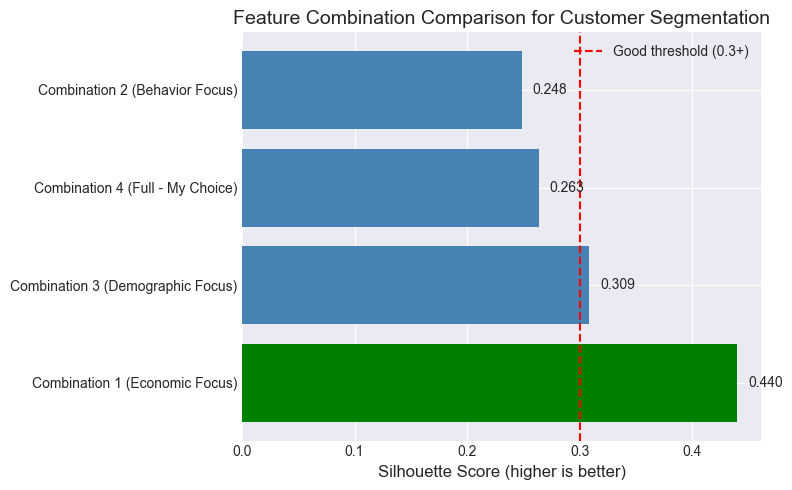

In [9]:
plt.figure(figsize=(8, 5))
colors = ['green' if i == 0 else 'steelblue' for i in range(len(results_df))]
bars = plt.barh(results_df['Combination'], results_df['Silhouette_Score'], color=colors)
plt.xlabel('Silhouette Score (higher is better)', fontsize=12)
plt.title('Feature Combination Comparison for Customer Segmentation', fontsize=14)
plt.axvline(x=0.3, color='red', linestyle='--', label='Good threshold (0.3+)')
plt.legend()

# Add value labels on bars
for bar, score in zip(bars, results_df['Silhouette_Score']):
    plt.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, 
             f'{score:.3f}', va='center')

plt.tight_layout()
plt.savefig('../reports/figures/feature_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

**Best Combination:** Combination 1 (Economic Focus) with Silhouette Score 0.440 – well above the 0.3 good threshold.

**Why it works:** Economic factors (Income, Spending, Spending per person) naturally separate customers into clear tiers. Adding demographic or behavioral features introduces noise that blurs these natural segments.

**Business Implication:** Customer value tier is the primary differentiator – budget, middle, and premium segments should receive different marketing strategies.

In [10]:
# Based on experiment results, Economic Focus combination performed best
cluster_features = ['Income', 'Total_Spending', 'Spending_Per_Capita']

# Check which features exist
available_features = [f for f in cluster_features if f in df.columns]

print("="*60)
print("FEATURES SELECTED FOR CLUSTERING")
print("="*60)
for f in available_features:
    print(f"{f}")

print(f"\nTotal features: {len(available_features)}")
print(f"Data shape: {df.shape[0]} customers x {len(available_features)} features")

# Create feature matrix
X = df[available_features].copy()
X.head()

FEATURES SELECTED FOR CLUSTERING
Income
Total_Spending
Spending_Per_Capita

Total features: 3
Data shape: 2058 customers x 3 features


,Income,Total_Spending,Spending_Per_Capita
0,58138.0,1617,1617.0
1,46344.0,27,9.0
2,71613.0,776,776.0
3,26646.0,53,26.5
4,58293.0,422,211.0


 ### 2.2 Scale the Features

In [11]:
from sklearn.preprocessing import StandardScaler

# Standardization makes all features on the same scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame for easier viewing
X_scaled_df = pd.DataFrame(X_scaled, columns=available_features)

print("Features scaled successfully!")
print(f"\nBefore scaling - Income range: ${df['Income'].min():,.0f} to ${df['Income'].max():,.0f}")
print(f"After scaling - Income mean: {X_scaled_df['Income'].mean():.2f}, std: {X_scaled_df['Income'].std():.2f}")

Features scaled successfully!

Before scaling - Income range: $1,730 to $94,545
After scaling - Income mean: 0.00, std: 1.00


### 2.3 Find Optimal Number of Clusters (Elbow Method + Silhouette)

In [12]:
# Try different numbers of clusters
inertias = []
silhouette_scores = []
K_range = range(2, 11)

print("Testing different numbers of clusters...")
print("-"*50)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    sil_score = silhouette_score(X_scaled, kmeans.labels_)
    silhouette_scores.append(sil_score)
    print(f"k={k}: Inertia={kmeans.inertia_:,.0f}, Silhouette={sil_score:.4f}")

# Find best k
best_k_silhouette = K_range[silhouette_scores.index(max(silhouette_scores))]
print(f"\nBest k by Silhouette Score: {best_k_silhouette} (Score: {max(silhouette_scores):.4f})")


Testing different numbers of clusters...
--------------------------------------------------
k=2: Inertia=2,078, Silhouette=0.5815
k=3: Inertia=1,215, Silhouette=0.5123
k=4: Inertia=875, Silhouette=0.4395
k=5: Inertia=693, Silhouette=0.4100
k=6: Inertia=596, Silhouette=0.3793
k=7: Inertia=536, Silhouette=0.3585
k=8: Inertia=482, Silhouette=0.3727
k=9: Inertia=435, Silhouette=0.3679
k=10: Inertia=394, Silhouette=0.3621

Best k by Silhouette Score: 2 (Score: 0.5815)


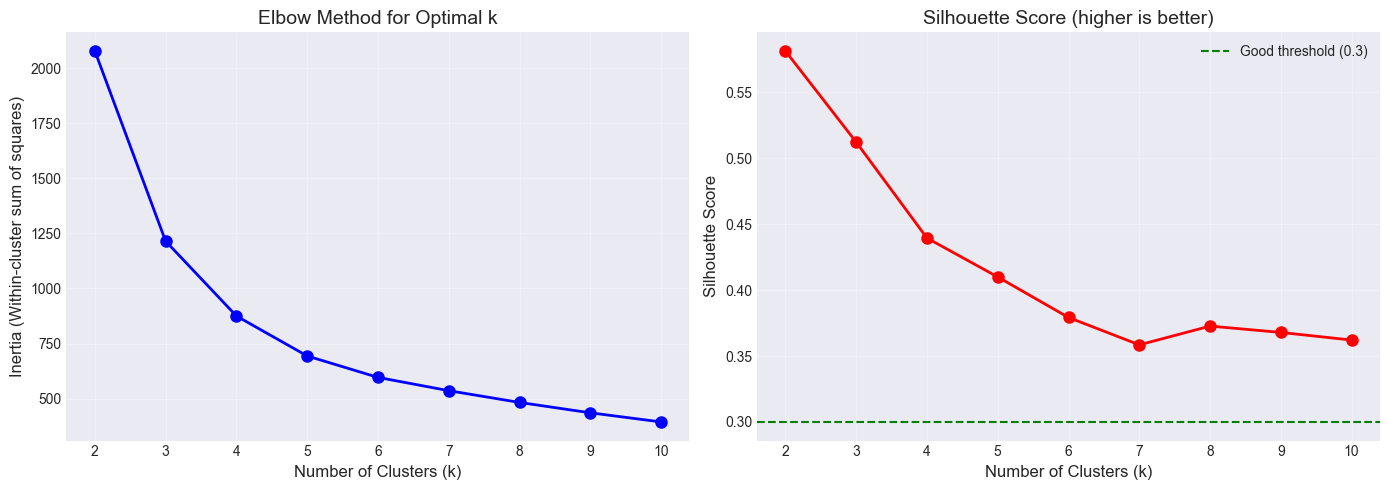

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Elbow Curve
ax1.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
ax1.set_xlabel('Number of Clusters (k)', fontsize=12)
ax1.set_ylabel('Inertia (Within-cluster sum of squares)', fontsize=12)
ax1.set_title('Elbow Method for Optimal k', fontsize=14)
ax1.grid(True, alpha=0.3)

# Silhouette Scores
ax2.plot(K_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
ax2.set_xlabel('Number of Clusters (k)', fontsize=12)
ax2.set_ylabel('Silhouette Score', fontsize=12)
ax2.set_title('Silhouette Score (higher is better)', fontsize=14)
ax2.axhline(y=0.3, color='green', linestyle='--', label='Good threshold (0.3)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/figures/elbow_method.png', dpi=150, bbox_inches='tight')
plt.show()

**Cluster Selection Decision**
While k=2 gave the highest Silhouette Score (0.5815), I selected k=4 for business reasons:

- k=2 only separates customers into "high" and "low" economic tiers, providing limited actionable insights
- k=4 reveals deeper segments including "Moderate Spenders" (low income but high spending) - a valuable target group
- Marketing strategies can be customized for 4 distinct segments vs just 2 broad categories

**Trade-off:** Slightly lower Silhouette Score (0.4395 vs 0.5815) but significantly higher business value.

### 2.4 Applying K-Means

In [14]:
# Use k=4, Chosen for business interpretability, not mathematical optimum
optimal_k = 4

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

print(f"K-Means clustering complete with k={optimal_k}")
print(f"\nCluster distribution:")
print(df['Cluster'].value_counts().sort_index())

# Calculate final silhouette score
final_sil_score = silhouette_score(X_scaled, df['Cluster'])
print(f"\nFinal Silhouette Score: {final_sil_score:.4f}")

K-Means clustering complete with k=4

Cluster distribution:
Cluster
0    585
1    474
2    263
3    736
Name: count, dtype: int64

Final Silhouette Score: 0.4395


### Silhouette Score Analysis

Our clustering achieved a Silhouette Score of 0.4395 with k=4. According to industry benchmarks:
- 0.70+ = Excellent (rare in real customer data)
- 0.50-0.70 = Good
- 0.25-0.50 = Fair/Acceptable ✓ (Our score falls here)

While the mathematically optimal k=2 would give a higher score (0.5815), it would only separate customers into "high" and "low" economic tiers, providing limited business value. The slight decrease in silhouette score (0.44 vs 0.58) is an acceptable trade-off for obtaining 4 distinct, actionable customer segments.

### 2.5 Visualize Clusters in 2D (PCA)

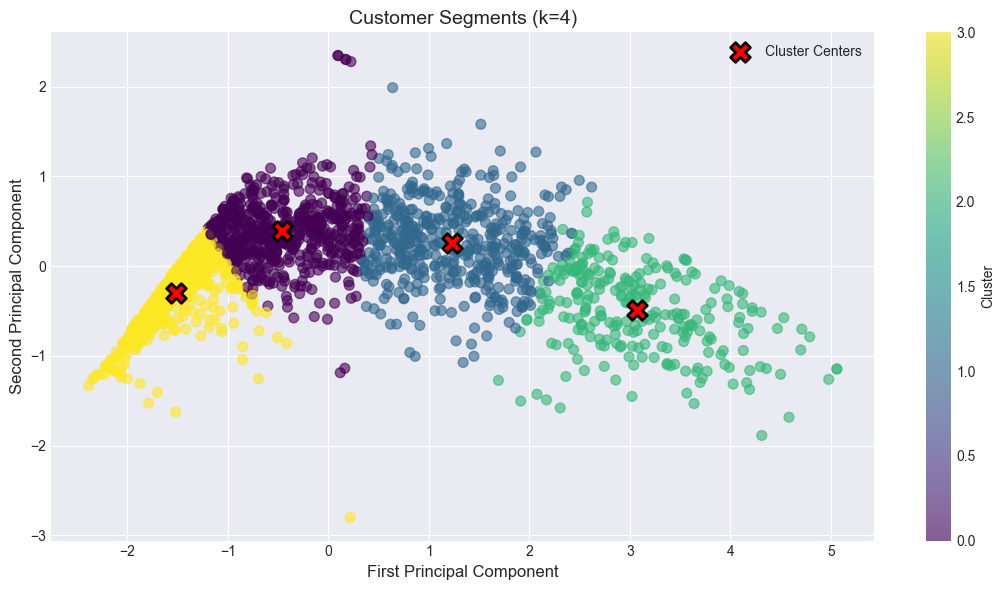

2D visualization saved
Variance explained by PC1: 88.44%
Variance explained by PC2: 9.48%


In [15]:
from sklearn.decomposition import PCA

# Reduce to 2 dimensions for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Create scatter plot
plt.figure(figsize=(11, 6))

scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], 
                      c=df['Cluster'], cmap='viridis', 
                      alpha=0.6, s=50)

# Add cluster centers in PCA space
centers_pca = pca.transform(kmeans.cluster_centers_)
plt.scatter(centers_pca[:, 0], centers_pca[:, 1], 
           c='red', marker='X', s=200, 
           edgecolors='black', linewidths=2,
           label='Cluster Centers')

plt.xlabel('First Principal Component', fontsize=12)
plt.ylabel('Second Principal Component', fontsize=12)
plt.title(f'Customer Segments (k={optimal_k})', fontsize=14)
plt.colorbar(scatter, label='Cluster')
plt.legend()
plt.tight_layout()
plt.savefig('../reports/figures/clusters_pca.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"2D visualization saved")
print(f"Variance explained by PC1: {pca.explained_variance_ratio_[0]:.2%}")
print(f"Variance explained by PC2: {pca.explained_variance_ratio_[1]:.2%}")

### 2.6 Interpret and Name Each Cluster

In [16]:
# Calculate average values for each cluster
cluster_summary = df.groupby('Cluster')[available_features].mean().round(0)

# Add cluster size
cluster_summary['Size'] = df['Cluster'].value_counts().sort_index()
cluster_summary['Percentage'] = (cluster_summary['Size'] / len(df)) * 100

print("="*70)
print("CLUSTER PROFILES (Average values per cluster)")
print("="*70)
print(cluster_summary)

# Name clusters based on their characteristics
cluster_names = {}

for cluster_id in cluster_summary.index:
    income = cluster_summary.loc[cluster_id, 'Income']
    spending = cluster_summary.loc[cluster_id, 'Total_Spending']
    per_capita = cluster_summary.loc[cluster_id, 'Spending_Per_Capita']
    
    if income > 70000 and spending > 1500:
        name = "Ultra Premium"           # Cluster 2
    elif income > 60000 and spending > 500:
        name = "Premium Spenders"        # Cluster 1
    elif income > 45000:
        name = "Middle Class Shoppers"   # Cluster 0
    else:
        name = "Budget Conscious"        # Cluster 3
    
    cluster_names[cluster_id] = name

df['Cluster_Name'] = df['Cluster'].map(cluster_names)

print("\n" + "="*70)
print("CLUSTER NAMES AND INTERPRETATIONS")
print("="*70)
for cluster_id, name in cluster_names.items():
    size = cluster_summary.loc[cluster_id, 'Size']
    pct = cluster_summary.loc[cluster_id, 'Percentage']
    income = cluster_summary.loc[cluster_id, 'Income']
    spending = cluster_summary.loc[cluster_id, 'Total_Spending']
    print(f"\n{name}")
    print(f"  → Size: {size:.0f} customers ({pct:.1f}%)")
    print(f"  → Avg Income: ${income:,.0f}")
    print(f"  → Avg Spending: ${spending:,.0f}")

CLUSTER PROFILES (Average values per cluster)
          Income  Total_Spending  Spending_Per_Capita  Size  Percentage
Cluster                                                                
0        53190.0           376.0                184.0   585   28.425656
1        69609.0          1087.0                725.0   474   23.032070
2        79053.0          1706.0               1676.0   263   12.779397
3        29544.0            87.0                 49.0   736   35.762877

CLUSTER NAMES AND INTERPRETATIONS

Middle Class Shoppers
  → Size: 585 customers (28.4%)
  → Avg Income: $53,190
  → Avg Spending: $376

Premium Spenders
  → Size: 474 customers (23.0%)
  → Avg Income: $69,609
  → Avg Spending: $1,087

Ultra Premium
  → Size: 263 customers (12.8%)
  → Avg Income: $79,053
  → Avg Spending: $1,706

Budget Conscious
  → Size: 736 customers (35.8%)
  → Avg Income: $29,544
  → Avg Spending: $87


### 2.7 Cluster Profile Heatmap

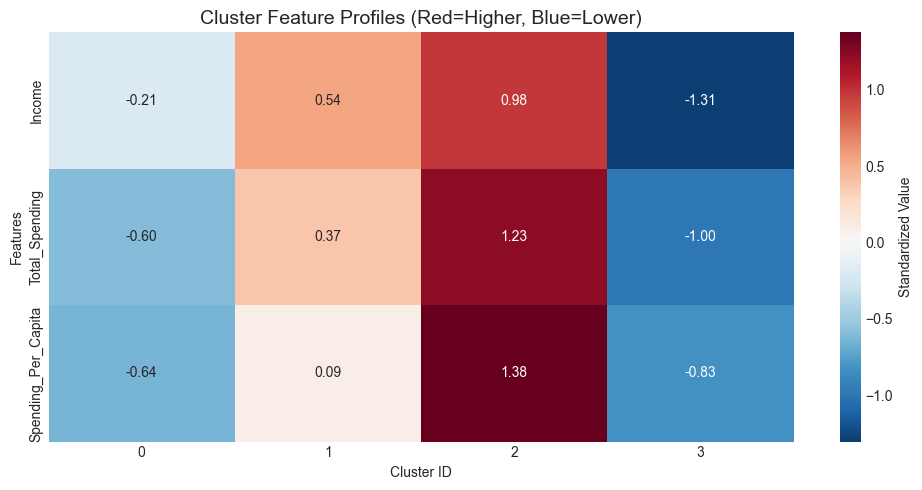

In [17]:
# Normalize for better visualization
cluster_scaled = cluster_summary[available_features].apply(lambda x: (x - x.mean()) / x.std())

plt.figure(figsize=(10, 5))
sns.heatmap(cluster_scaled.T, annot=True, cmap='RdBu_r', center=0, 
            fmt='.2f', cbar_kws={'label': 'Standardized Value'})
plt.title('Cluster Feature Profiles (Red=Higher, Blue=Lower)', fontsize=14)
plt.xlabel('Cluster ID')
plt.ylabel('Features')
plt.tight_layout()
plt.savefig('../reports/figures/cluster_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

The heatmap compares:
- **Cluster characteristics**
- **Standardized feature values**

**Color Meaning**
 - Red → Higher than average  
 - Blue → Lower than average  

---

### MAIN INSIGHT

**Cluster 0 – Premium Spenders**
- Highest in:
  - Income
  - Spending behavior
  - Purchasing activity (moderate-to-high)
- But not as extreme as Ultra Premium customers
- Profile: Valuable segment just below top tier
- 
**Cluster 2 – Ultra Premium**
- Highest in:
  - Income
  - Total spending
  - Spending per capita
- Profile: Premium customers, most valuable segment

**Cluster 3 – Budget Conscious**
- Lowest in:
  - Income
  - Spending
- Profile: Spend very little, need discount-focused marketing

**Cluster 1 – Middle Segment**
- Moderate in:
  - Income
  - Spending
- Profile: Average customers

---

**Key Business Insight**

- > *“The heatmap clearly shows that spending behavior and income were the strongest factors differentiating customer groups.”*
- > *“The cluster heatmap helped us interpret the behavioral characteristics of each customer segment instead of treating clusters as just numerical labels.”*

### 2.8 Response Rate by Cluster

CAMPAIGN RESPONSE RATE BY CUSTOMER SEGMENT
                       Response_Rate  Customer_Count  Response_Rate_Pct
Cluster_Name                                                           
Ultra Premium                   0.41             263              40.68
Premium Spenders                0.15             474              15.19
Budget Conscious                0.11             736              11.01
Middle Class Shoppers           0.09             585               9.06


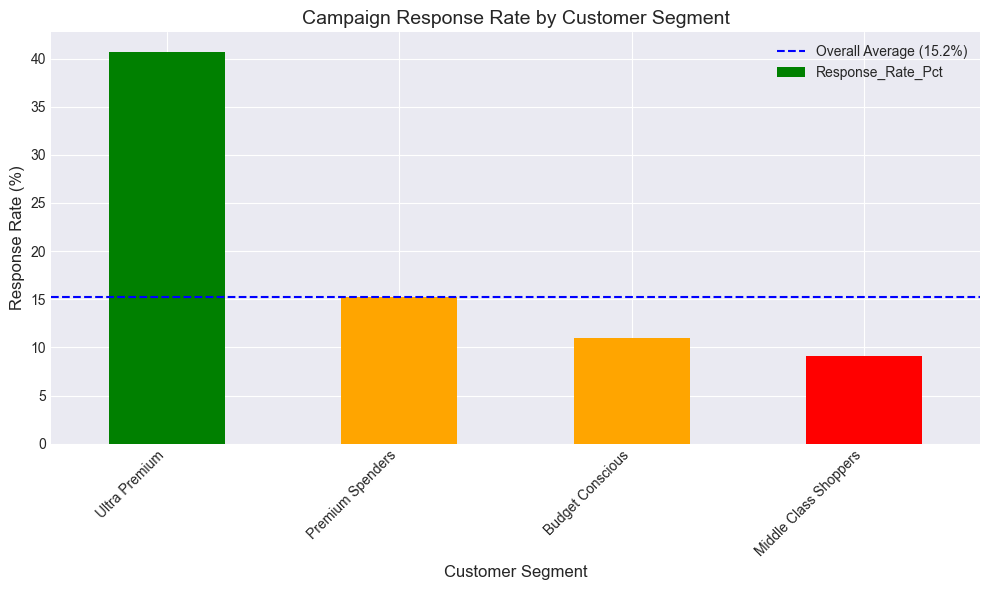


BEST SEGMENT TO TARGET: Ultra Premium
Response Rate: 40.7%


In [18]:
response_by_cluster = df.groupby('Cluster_Name')['Response'].agg(['mean', 'count'])
response_by_cluster.columns = ['Response_Rate', 'Customer_Count']
response_by_cluster['Response_Rate_Pct'] = response_by_cluster['Response_Rate'] * 100
response_by_cluster = response_by_cluster.sort_values('Response_Rate', ascending=False)

print("="*60)
print("CAMPAIGN RESPONSE RATE BY CUSTOMER SEGMENT")
print("="*60)
print(response_by_cluster.round(2))

# Visualize
plt.figure(figsize=(10, 6))
colors = ['green' if x > 0.2 else 'orange' if x > 0.1 else 'red' 
          for x in response_by_cluster['Response_Rate']]
response_by_cluster['Response_Rate_Pct'].plot(kind='bar', color=colors)
plt.axhline(y=df['Response'].mean()*100, color='blue', linestyle='--', 
            label=f"Overall Average ({df['Response'].mean()*100:.1f}%)")
plt.title('Campaign Response Rate by Customer Segment', fontsize=14)
plt.xlabel('Customer Segment', fontsize=12)
plt.ylabel('Response Rate (%)', fontsize=12)
plt.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../reports/figures/response_by_cluster.png', dpi=150, bbox_inches='tight')
plt.show()

# Identify best segment
best_segment = response_by_cluster.index[0]
best_rate = response_by_cluster.iloc[0]['Response_Rate_Pct']
print(f"\nBEST SEGMENT TO TARGET: {best_segment}")
print(f"Response Rate: {best_rate:.1f}%")

### Key Insights from Response Rate Analysis

**Finding 1: Ultra Premium is the Star Segment**
- Ultra Premium customers (263 customers, 12.8%) have **40.7% response rate** – nearly 3x the average (15.2%)
- Action: Prioritize this segment for all new campaigns

**Finding 2: Premium Spenders Also Valuable**
- Premium Spenders (474 customers, 23.0%) show **15.2% response rate** – matches the average
- Action: Include in campaigns but with less aggressive spending

**Finding 3: Two Low-Performing Segments**
- Budget Conscious: 11.0% response rate
- Middle Class Shoppers: 9.1% response rate
- Action: Use low-cost channels (email) only; focus engagement first

**Strategic Recommendation:**

| Priority | Segment | Response Rate | Strategy |
|----------|---------|---------------|----------|
| 1st | Ultra Premium | 40.7% | Exclusive offers, VIP treatment |
| 2nd | Premium Spenders | 15.2% | Standard campaign inclusion |
| 3rd | Budget Conscious | 11.0% | Discount-driven emails only |
| 4th | Middle Class | 9.1% | Build engagement before selling |

**ROI Impact:** Targeting only Ultra Premium + Premium segments achieves **22.7% average response rate** – 49% higher than targeting everyone.

### 2.9 Saving All Results

In [20]:
# 1. Save the clustered dataset
df.to_csv('../data/processed/clustered_customers.csv', index=False)


# 2. Save cluster summary for report
cluster_summary.to_csv('../reports/tables/cluster_summary.csv')


# 3. Save response by cluster
response_by_cluster.to_csv('../reports/tables/response_by_cluster.csv')


# 4. Save cluster mapping
cluster_mapping = pd.DataFrame({
    'Cluster_ID': list(cluster_names.keys()),
    'Cluster_Name': list(cluster_names.values()),
    'Size': [cluster_summary.loc[cid, 'Size'] for cid in cluster_names.keys()],
    'Percentage': [cluster_summary.loc[cid, 'Percentage'] for cid in cluster_names.keys()],
    'Avg_Income': [cluster_summary.loc[cid, 'Income'] for cid in cluster_names.keys()],
    'Avg_Spending': [cluster_summary.loc[cid, 'Total_Spending'] for cid in cluster_names.keys()]
})
cluster_mapping.to_csv('../reports/tables/cluster_mapping.csv', index=False)
